In [1]:
%matplotlib notebook
%matplotlib inline
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append("..")
sys.path.append("../outsource/encoder4editing/")
from utils.model_utils import setup_model
import argparse
import pdb
import torch
from torch.utils.data import DataLoader

from lib import utils, models_loader, data_loader
import torch.nn.functional as F

device ="cuda" if torch.cuda.is_available() else "cpu"

In [2]:
def parser_parameters():
    parser = argparse.ArgumentParser(description="Inference")
    parser.add_argument("--ckpt_generator", metavar="CHECKPOINT", default='../models/e4e_ffhq_encode.pt', help="path to generator checkpoint")
    parser.add_argument("--path2dir_segImg", type=str, default="../data/CelebAHQ-500samples")
    parser.add_argument("--prompts_file", type=str, default="../data/prompts.txt")
    
    parser.add_argument("--path2log_textseg2w", type=str, default="../models/text_seg2latent")  
    parser.add_argument("--name_seg", type=str, default='epoch=267-loss-l1=0.2001-cos=0.2274.ckpt') 

    parser.add_argument("--path2log_textsketch2w", type=str, default="../models/text_sketch2latent")   
    parser.add_argument("--name_sketch", type=str, default='epoch=472-loss-l1=0.2091-cos=0.2428.ckpt') 
    
    args = parser.parse_args("")
    return args

args = parser_parameters()

In [3]:
net, opts = setup_model(args.ckpt_generator, device)
generator = net.decoder
generator.eval()

clip_farl, clip_preprocess = models_loader.load_clip('farl_ep16', device)
clip_vitb32, _ = models_loader.load_clip("vit32", device)

Loading e4e over the pSp framework from checkpoint: ../models/e4e_ffhq_encode.pt


In [4]:
model_textseg2w = utils.load_module(args.path2log_textseg2w, "models_arch").BiPathModel().to(device)
model_textseg2w.load_state_dict(torch.load(os.path.join(args.path2log_textseg2w, args.name_seg))["state_dict"])
model_textseg2w.eval();

In [8]:
model_txtsketch2w = utils.load_module(args.path2log_textsketch2w, "models_arch").BiPathModel().to(device)
model_txtsketch2w.load_state_dict(torch.load(os.path.join(args.path2log_textsketch2w, args.name_sketch))["state_dict"])
model_txtsketch2w.eval();

In [9]:
''' text+Plus to image generation'''
@torch.no_grad()
def image_generation(seg_of_data, mapmodel, map_type = 'seg', n_batch_control=1, ):
    figsize = (18, 18)
    num_image = seg_of_data[0] * n_batch_control
    nrow = n_batch_control

    text_dataset = data_loader.TextLoader(args.prompts_file, clip_farl, clip_vitb32, device)
    torch_data_loader = DataLoader(text_dataset, batch_size=1, drop_last=False)
    text_dataset.show_data()

    control_dataset = data_loader.load_demo_data(args.path2dir_segImg, ["2548.seg_gray_facerCeleb.png", "4422.seg_gray_facerCeleb.png", "14868.seg_gray_facerCeleb.png", "9967.seg_gray_facerCeleb.png", "20122.seg_gray_facerCeleb.png"], stage='inference')
    control_dataloader = DataLoader(control_dataset, batch_size=n_batch_control, drop_last=False)

    rgbImg_norm1024, segImg_norm128, sketch_norm256, seg_embed, sketch_emb = next(iter(control_dataloader))
    
    segImg_embedding = seg_embed.to(device).reshape(n_batch_control, -1)
    sketch_emb = sketch_emb.to(device).reshape(n_batch_control, -1)
    
    seg_norm_1024 = F.interpolate(segImg_norm128, size=(1024, 1024), mode='nearest').to(device)
    sketch_norm_1024 = F.interpolate(sketch_norm256, size=(1024, 1024), mode='nearest').to(device)

    ori_images = []
    syn_images = []
    seg_images = []
    sketch_images = []

    for idx, (norm_features_, _) in enumerate(torch_data_loader):
        if seg_of_data[0] * seg_of_data[1] <= idx < seg_of_data[0] * (seg_of_data[1] + 1):

            norm_features_repeat = norm_features_.repeat(n_batch_control, 1).to(device)
            if map_type == "seg":
                TextClip_segEmbed = torch.cat([norm_features_repeat, segImg_embedding], dim=1)
                image_norm_syn = utils.clipfeature2image_tensor(TextClip_segEmbed, mapmodel, generator)

                
            elif map_type == "sketch":
                textEmb_sketch = torch.cat([norm_features_repeat, sketch_emb], dim=1)
                image_norm_syn = utils.clipfeature2image_tensor(textEmb_sketch, mapmodel, generator)
            
            ori_images.append(rgbImg_norm1024 * 0.7 + 0.3)
            seg_images.append(seg_norm_1024)
            syn_images.append(image_norm_syn)
            sketch_images.append(sketch_norm_1024)

    batch_syn_images = torch.cat(syn_images)
    batch_seg_images = torch.cat(seg_images) 
    batch_seg_images = torch.cat([batch_seg_images, batch_seg_images, batch_seg_images], dim=1)
    batch_sketch_images = torch.cat(sketch_images)

    image_01_syn = utils.tensor2image_dim4(batch_syn_images)
    
    image_grid_syn = utils.tensor2grid_image(image_01_syn.cpu(), num_image, nrow)
    if map_type == "seg":
        image_grid_syn = utils.tensor2grid_image(torch.cat([image_01_syn, batch_seg_images], dim=2).cpu(), num_image, nrow)
    elif map_type == "sketch":
        image_grid_syn = utils.tensor2grid_image(torch.cat([image_01_syn, batch_sketch_images], dim=2).cpu(), num_image, nrow)
    utils.show_image(image_grid_syn, figsize)
    return image_grid_syn



1	A photograph of a young man with a beard
2	A photograph of a old woman's face with grey hair
3	A photograph of a child at a birthday party
4	A picture of a face outside in bright sun in front of green grass
5	This man has bangs arched eyebrows curly hair and a small nose
6	A photo of Barack Obama
7	An arctic explorer
8	A clown's face covered in make up
9	A photo of an old person by the beach
10	A portrait of Angela Merkel
11	Young boy with sunglasses and an angry face
12	Middle aged man with a moustache and a happy expression
13	The face of a person who just finished running a marathon
14	A vampire's face
15	An office worker wearing a shirt looking stressed
16	The Mona Lisa


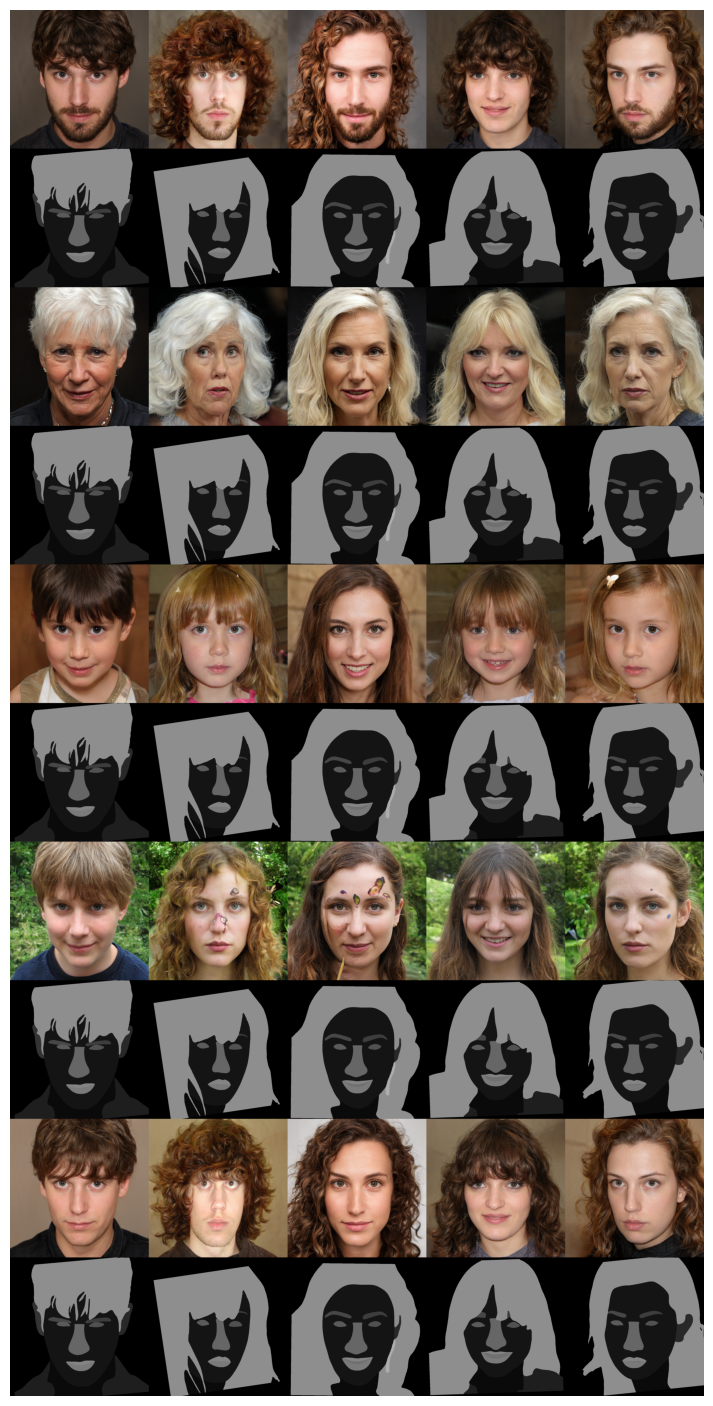

In [12]:
%matplotlib notebook
%matplotlib inline

image_toshow = image_generation(seg_of_data=[5, 0], mapmodel=model_textseg2w, map_type = 'seg', n_batch_control=5)
# image_toshow = image_generation(seg_of_data=[5, 0], mapmodel=model_txtsketch2w, map_type = 'sketch', n_batch_control=5)